# Heart Disease Risk Prediction Using Machine Learning  


#### **Dataset Source**
Heart Disease Diagnosis Dataset  
https://www.kaggle.com/datasets/utkarshx27/heart-disease-diagnosis-dataset  

---

#### **Project Description**
<sub>
This project aims to predict heart disease risk using machine learning techniques based on patient medical data.  
The dataset includes features such as age, cholesterol, blood pressure, heart rate, and other medical attributes.
</sub>


**Date:** April 2026

In [ ]:
# Import required libraries
# pandas → data handling
# numpy → numerical operations
# matplotlib → plotting graphs
# seaborn → visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [ ]:
# ==========================================
# Upload dataset to Google Colab
# ==========================================

from google.colab import files

uploaded = files.upload()


# ==========================================
# Load dataset into dataframe
# ==========================================

import pandas as pd

# Read CSV file (use correct file name)

df = pd.read_csv("heart_dataset.csv")

# Display first 5 rows

print("First 10 rows of dataset:")
df.head()


Saving heart_dataset.csv to heart_dataset.csv
First 10 rows of dataset:


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,max_heart_rate,exercise_induced_angina,oldpeak,st_segment,major_vessels,thal,heart_disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


In [ ]:
# ==========================================
# Explore Dataset Information
# ==========================================

# Display dataset size

print("Dataset Shape:")
print(df.shape)

# Display column names and types

print("\nDataset Info:")
df.info()

# Statistical summary

print("\nStatistical Summary:")
df.describe()

Dataset Shape:
(270, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest_pain_type                       270 non-null    int64  
 3   resting_blood_pressure                270 non-null    int64  
 4   serum_cholestoral                     270 non-null    int64  
 5   fasting_blood_sugar                   270 non-null    int64  
 6   resting_electrocardiographic_results  270 non-null    int64  
 7   max_heart_rate                        270 non-null    int64  
 8   exercise_induced_angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  st_segment                            270 non-

,age,sex,chest_pain_type,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,max_heart_rate,exercise_induced_angina,oldpeak,st_segment,major_vessels,thal,heart_disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


In [ ]:
# ==========================================
# Check Missing Values
# ==========================================

print("Missing Values in Each Column:")

df.isnull().sum()

Missing Values in Each Column:


,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
serum_cholestoral,0
fasting_blood_sugar,0
resting_electrocardiographic_results,0
max_heart_rate,0
exercise_induced_angina,0
oldpeak,0


In [ ]:
# ==========================================
# Remove Duplicate Records
# ==========================================

df = df.drop_duplicates()

print("Duplicate records removed.")

# Check new shape

print("Updated Dataset Shape:")
print(df.shape)

Duplicate records removed.
Updated Dataset Shape:
(270, 14)


In [ ]:
# Show column names

print(df.columns)

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'serum_cholestoral', 'fasting_blood_sugar',
       'resting_electrocardiographic_results', 'max_heart_rate',
       'exercise_induced_angina', 'oldpeak', 'st_segment', 'major_vessels',
       'thal', 'heart_disease'],
      dtype='object')


In [ ]:
# ==========================================
# Clean Column Names
# ==========================================

# Remove spaces
df.columns = df.columns.str.strip()

# Replace spaces with underscore
df.columns = df.columns.str.replace(" ", "_")

# Convert to lowercase
df.columns = df.columns.str.lower()

print("Updated Column Names:")
print(list(df.columns))

Updated Column Names:
['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'st_segment', 'major_vessels', 'thal', 'heart_disease']


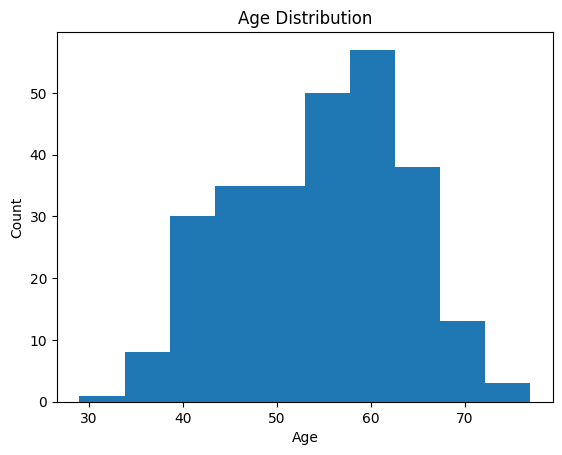

In [ ]:
# ==========================================
# Age Distribution
# ==========================================

plt.figure()

plt.hist(df['age'])

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

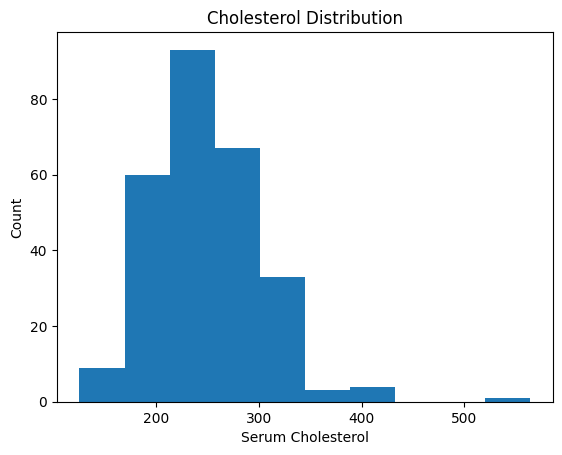

In [ ]:
# ==========================================
# Cholesterol Distribution
# ==========================================

plt.figure()

plt.hist(df['serum_cholestoral'])

plt.title("Cholesterol Distribution")

plt.xlabel("Serum Cholesterol")

plt.ylabel("Count")

plt.show()

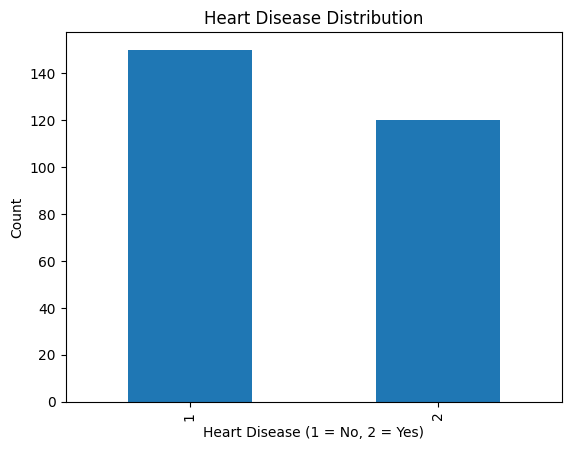

In [ ]:
# ==========================================
# Heart Disease Distribution
# ==========================================

plt.figure()

df['heart_disease'].value_counts().plot(kind='bar')

plt.title("Heart Disease Distribution")

plt.xlabel("Heart Disease (1 = No, 2 = Yes)")

plt.ylabel("Count")

plt.show()

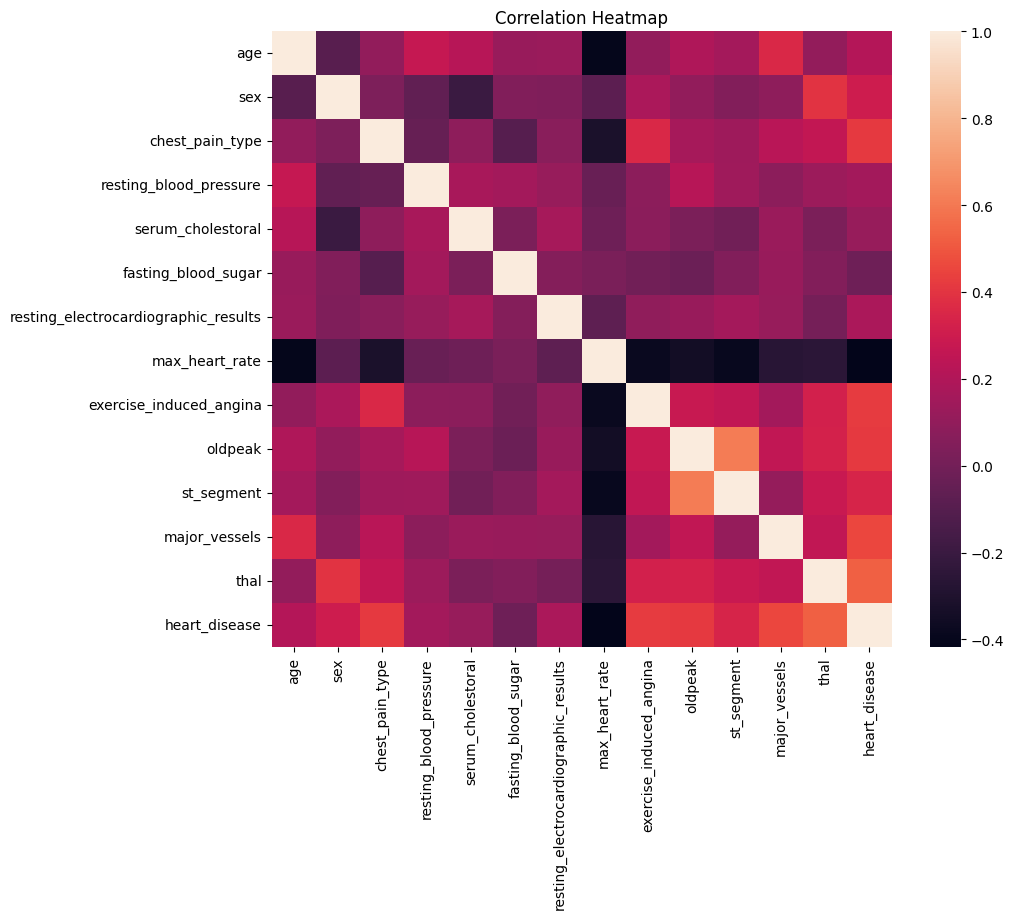

In [ ]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=False)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# ==========================================
# Separate Features and Target
# ==========================================

X = df.drop('heart_disease', axis=1)

y = df['heart_disease']

print("Features and target separated.")

Features and target separated.


In [ ]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print("Train-Test Split Completed.")

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Train-Test Split Completed.
Training Shape: (216, 13)
Testing Shape: (54, 13)


In [ ]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [ ]:
# ==========================================
# Save Clean Dataset
# ==========================================

df.to_csv("heart_cleaned.csv", index=False)

print("Clean dataset saved.")

Clean dataset saved.


Logistic Regression Model

In [ ]:
# ==========================================
# Logistic Regression model
# ==========================================

#create logistic regression model
#max_iter=1000 ensures the model has enough iterations to coverage
log_model = LogisticRegression(max_iter=1000, random_state=42)

# train model using training data
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
# ==========================================
# Logistic Regression prediction and accuracy
# ==========================================

#use the trained model to make predictions on the test data
y_pred_log = log_model.predict(X_test_scaled)

# calculate accuracy to evaluate how well the model predicts heart disease
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.9074074074074074


The Logistic Regression model achieved an accuracy of 90.7%, indicating strong predictive performance in identifying heart disease cases.

Confusion Matrix:
 [[31  2]
 [ 3 18]]


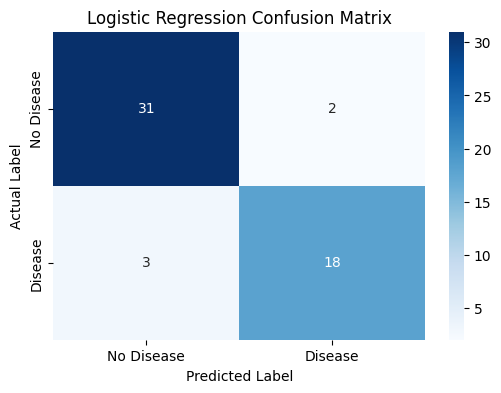

In [ ]:
# ==========================================
# Confusion Matrix
# ==========================================

#generate confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

print("Confusion Matrix:\n", cm_log)

# create heatmap visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log,
            annot=True,       # show numbers inside boxes
            fmt='d',          # integer format
            cmap='Blues')     # color theme

# add labels and title
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression Confusion Matrix")

plt.xticks([0.5, 1.5], ["No Disease", "Disease"])
plt.yticks([0.5, 1.5], ["No Disease", "Disease"])

plt.show()

The confusion matrix shows that the model correctly predicted 31 negative cases and 18 positive cases. There were 2 false positives and 3 false negatives, indicating that the model performs well overall with only a small number of misclassifications.

Decision Tree

In [ ]:
# ==========================================
# Train Decision Tree
# ==========================================

# create decision tree model
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# train using original data (no scaling needed)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [ ]:
# ==========================================
#  Decision Tree Prediction and Accuracy
# ==========================================

# use the trained decision tree model to make predictions on the test data
y_pred_dt = dt_model.predict(X_test)

# calculate accuracy by comparing predictions with actual values
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy", dt_accuracy)

Decision Tree Accuracy 0.7222222222222222


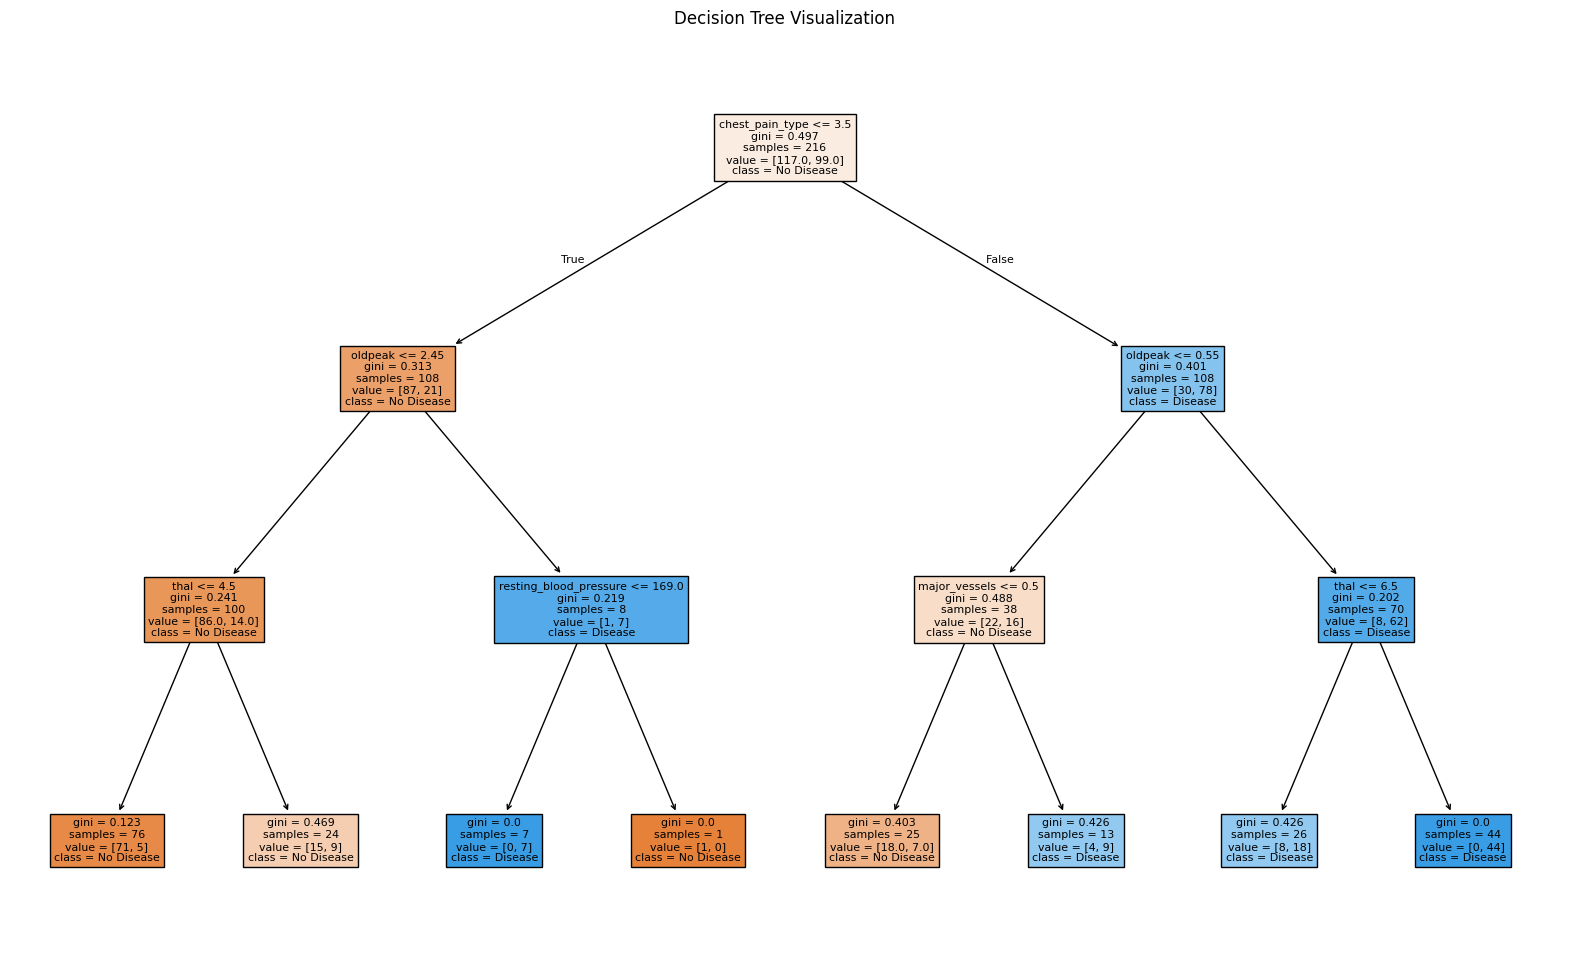

In [ ]:
# ==========================================
#  Decision Tree visualization
# ==========================================

plt.figure(figsize=(20, 12))

plot_tree(dt_model,
          feature_names=X.columns,
          class_names=["No Disease", "Disease"],
          filled=True,
          max_depth=3)

plt.title("Decision Tree Visualization")
plt.show()

The decision tree model was developed to classify whether a patient has heart deisease based on medical features. Initially, the model showed lower performance due to overfitting, as it created a very complex tree structured. To address this, the model complexity was reduced by limiting the tree depth using max_depth =3.
This adjustment increased the accuracy from approximately 68% to 72%. Logistic regression remains better model with accuracy at 90.7%.

In [ ]:
# ==========================================
#  Decision Tree Confusion Matrix
# ==========================================

# generate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)


print("Decision Tree Confusion Matrix:\n", cm_dt)

Decision Tree Confusion Matrix:
 [[26  7]
 [ 8 13]]


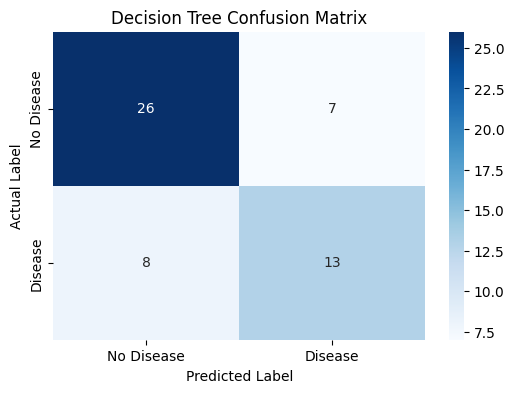

In [ ]:
# ==========================================
#  Decision Tree Confusion Matrix Heatmap
# ==========================================

plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Decision Tree Confusion Matrix")

plt.xticks([0.5, 1.5], ["No Disease", "Disease"])
plt.yticks([0.5, 1.5], ["No Disease", "Disease"])

plt.show()

The confusion matrix shows the model has more misclassifications compared to Logistic Regression, including 7 false positives and 8 false negatives. This indicates weaker performance, especially in identifying patients with heart disease.

In [ ]:
# ==========================================
# MODEL 3: K-NEAREST NEIGHBORS (KNN)
# Member 4 — Imen Farrah
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, precision_score,
                             recall_score, f1_score)
from sklearn.inspection import permutation_importance

print("KNN libraries imported successfully.")

KNN libraries imported successfully.


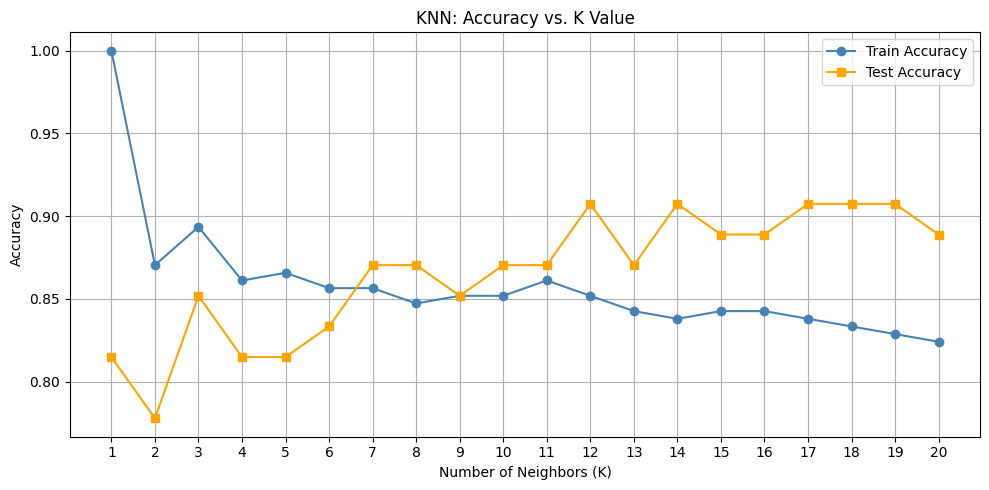

Best K: 12  |  Best Test Accuracy: 0.9074


In [ ]:
# ==========================================
# Find Optimal K Value
# ==========================================

# Test k from 1 to 20 and compare train vs test accuracy
k_values       = range(1, 21)
train_acc_list = []
test_acc_list  = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc_list.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_acc_list.append(accuracy_score(y_test,  knn.predict(X_test_scaled)))

# Plot accuracy vs K
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_acc_list, label='Train Accuracy', marker='o', color='steelblue')
plt.plot(k_values, test_acc_list,  label='Test Accuracy',  marker='s', color='orange')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs. K Value')
plt.legend()
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

# Select best K
best_k = list(k_values)[test_acc_list.index(max(test_acc_list))]
print(f"Best K: {best_k}  |  Best Test Accuracy: {max(test_acc_list):.4f}")

In [ ]:
# ==========================================
# Train KNN Model with Best K
# ==========================================

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

print(f"KNN model trained successfully with K = {best_k}.")

KNN model trained successfully with K = 12.


In [ ]:
# ==========================================
# KNN Prediction and Accuracy
# ==========================================

# Make predictions on test data
y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"KNN Accuracy (K={best_k}):", knn_accuracy)

KNN Accuracy (K=12): 0.9074074074074074


KNN Confusion Matrix:
 [[33  0]
 [ 5 16]]


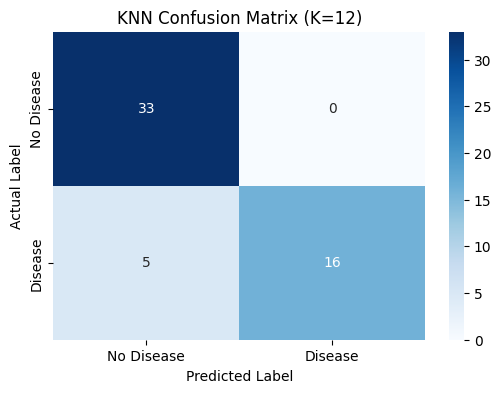

In [ ]:
# ==========================================
# KNN Confusion Matrix
# ==========================================

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:\n", cm_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(f"KNN Confusion Matrix (K={best_k})")

plt.xticks([0.5, 1.5], ["No Disease", "Disease"])
plt.yticks([0.5, 1.5], ["No Disease", "Disease"])

plt.show()

In [ ]:
# ==========================================
# KNN Classification Report
# ==========================================

print(f"KNN Classification Report (K={best_k}):")
print(classification_report(y_test, y_pred_knn,
                             target_names=['No Disease', 'Disease']))

KNN Classification Report (K=12):
              precision    recall  f1-score   support

  No Disease       0.87      1.00      0.93        33
     Disease       1.00      0.76      0.86        21

    accuracy                           0.91        54
   macro avg       0.93      0.88      0.90        54
weighted avg       0.92      0.91      0.90        54



In [ ]:
# ==========================================
# Collect Metrics — All 3 Models
# ==========================================

# Logistic Regression metrics
log_precision = precision_score(y_test, y_pred_log)
log_recall    = recall_score(y_test, y_pred_log)
log_f1        = f1_score(y_test, y_pred_log)

# Decision Tree metrics
dt_precision  = precision_score(y_test, y_pred_dt)
dt_recall     = recall_score(y_test, y_pred_dt)
dt_f1         = f1_score(y_test, y_pred_dt)

# KNN metrics
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall    = recall_score(y_test, y_pred_knn)
knn_f1        = f1_score(y_test, y_pred_knn)

print("Metrics collected for all three models.")

Metrics collected for all three models.


In [ ]:
# ==========================================
# Model Comparison — Summary Table
# ==========================================

import pandas as pd

comparison_df = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Decision Tree', f'KNN (K={best_k})'],
    'Accuracy' : [round(log_accuracy,  4), round(dt_accuracy,  4), round(knn_accuracy,  4)],
    'Precision': [round(log_precision, 4), round(dt_precision, 4), round(knn_precision, 4)],
    'Recall'   : [round(log_recall,    4), round(dt_recall,    4), round(knn_recall,    4)],
    'F1-Score' : [round(log_f1,        4), round(dt_f1,        4), round(knn_f1,        4)]
})

print("=" * 60)
print("          MODEL COMPARISON SUMMARY")
print("=" * 60)
print(comparison_df.to_string(index=False))
print("=" * 60)

          MODEL COMPARISON SUMMARY
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9074     0.9118  0.9394    0.9254
      Decision Tree    0.7222     0.7647  0.7879    0.7761
         KNN (K=12)    0.9074     0.8684  1.0000    0.9296


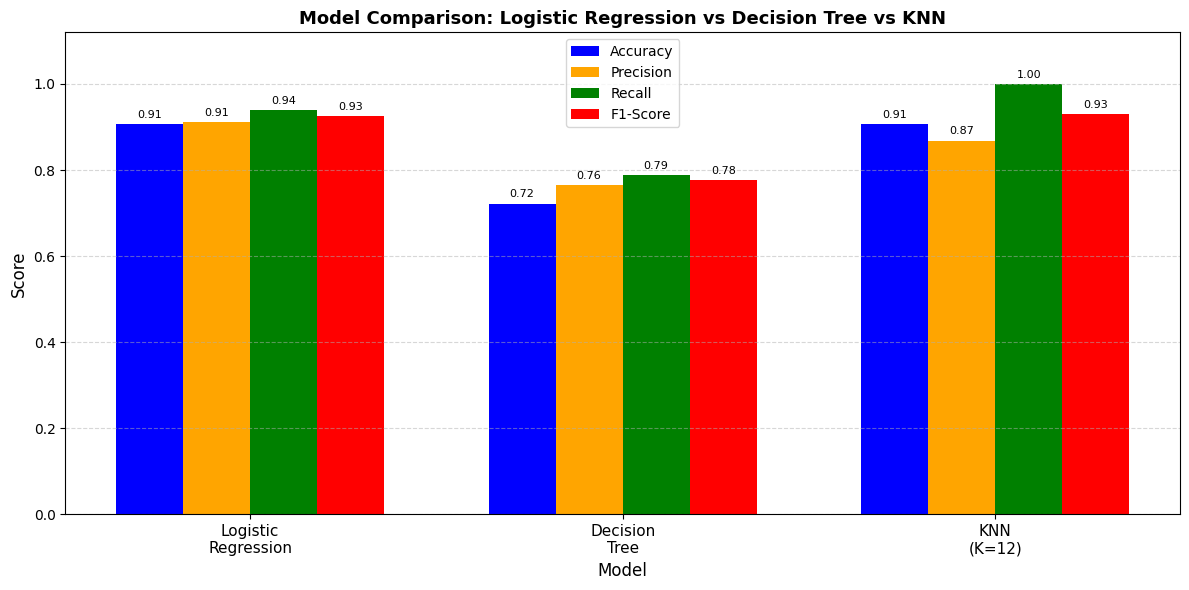

In [ ]:
# ==========================================
# Model Comparison — Bar Chart
# ==========================================

models    = ['Logistic\nRegression', 'Decision\nTree', f'KNN\n(K={best_k})']
metrics   = {
    'Accuracy' : [log_accuracy,  dt_accuracy,  knn_accuracy],
    'Precision': [log_precision, dt_precision, knn_precision],
    'Recall'   : [log_recall,    dt_recall,    knn_recall],
    'F1-Score' : [log_f1,        dt_f1,        knn_f1]
}
colors = ['blue', 'orange', 'green', 'red']

x     = np.arange(len(models))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))

for i, (metric_name, values) in enumerate(metrics.items()):
    bars = ax.bar(x + (i - 1.5) * width, values, width,
                  label=metric_name, color=colors[i])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Logistic Regression vs Decision Tree vs KNN',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

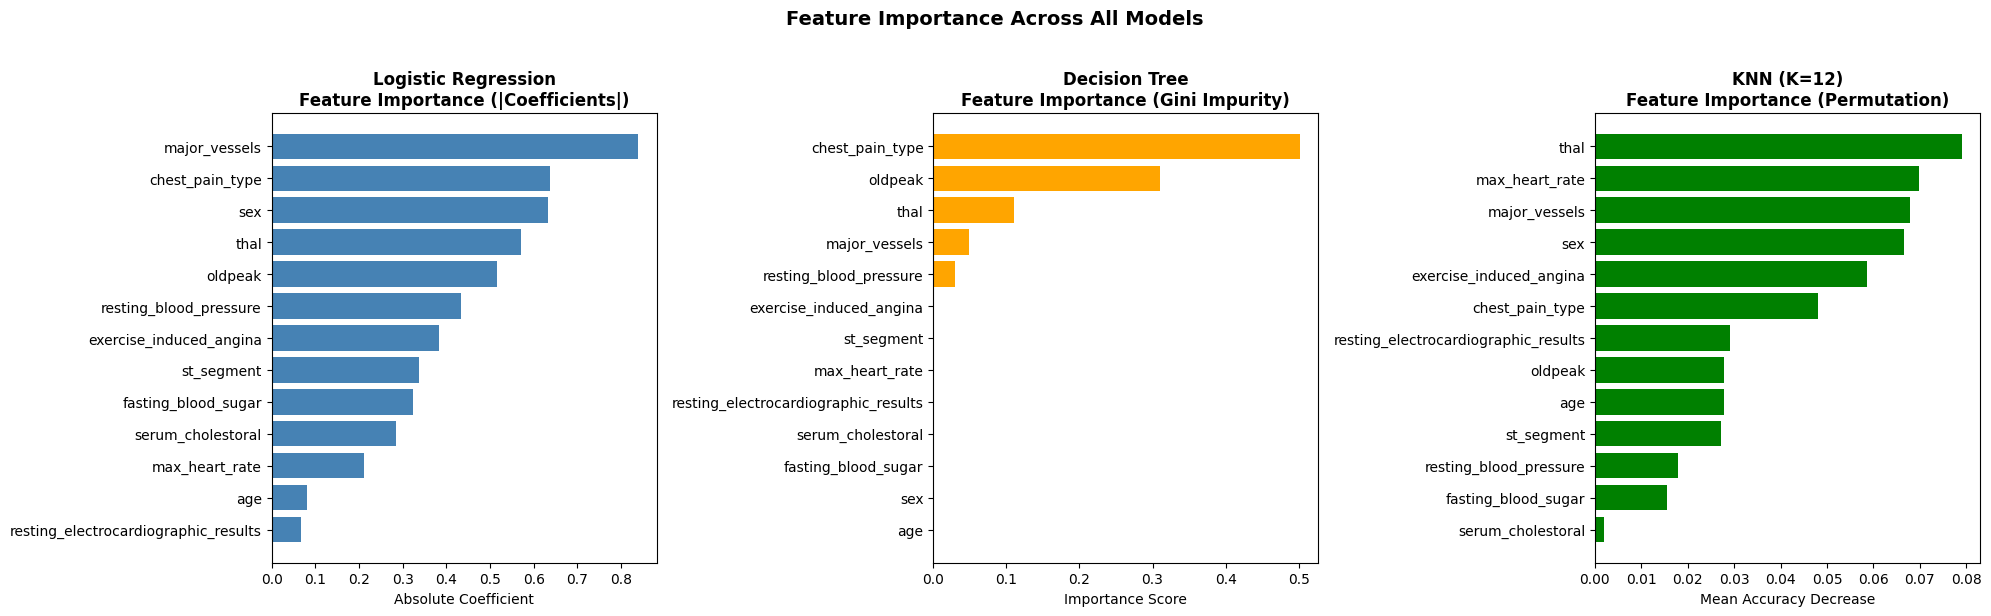

In [ ]:
# ==========================================
# Feature Importance — All 3 Models
# ==========================================

feature_names = list(X.columns)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Logistic Regression: uses coefficients ---
lr_importance = np.abs(log_model.coef_[0])
sorted_idx_lr = np.argsort(lr_importance)

axes[0].barh([feature_names[i] for i in sorted_idx_lr],
             lr_importance[sorted_idx_lr], color='steelblue')
axes[0].set_title('Logistic Regression\nFeature Importance (|Coefficients|)',
                  fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient')

# --- Decision Tree: built-in feature importance ---
dt_importance  = dt_model.feature_importances_
sorted_idx_dt  = np.argsort(dt_importance)

axes[1].barh([feature_names[i] for i in sorted_idx_dt],
             dt_importance[sorted_idx_dt], color='orange')
axes[1].set_title('Decision Tree\nFeature Importance (Gini Impurity)',
                  fontweight='bold')
axes[1].set_xlabel('Importance Score')

# --- KNN: uses permutation importance (KNN has no built-in) ---
perm_result  = permutation_importance(knn_model, X_test_scaled, y_test,
                                      n_repeats=30, random_state=42)
knn_importance = perm_result.importances_mean
sorted_idx_knn = np.argsort(knn_importance)

axes[2].barh([feature_names[i] for i in sorted_idx_knn],
             knn_importance[sorted_idx_knn], color='green')
axes[2].set_title(f'KNN (K={best_k})\nFeature Importance (Permutation)',
                  fontweight='bold')
axes[2].set_xlabel('Mean Accuracy Decrease')

plt.suptitle('Feature Importance Across All Models', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Model 3: K-Nearest Neighbors (KNN) — Summary

KNN classifies each patient by looking at the K closest patients in the training data and assigning the majority class.
Unlike Logistic Regression and Decision Tree, KNN requires feature scaling (already applied) and has no built-in feature importance — permutation importance was used instead.

The optimal K value was selected by comparing train vs. test accuracy across K = 1 to 20.

**Key Observations:**
- Logistic Regression achieved the highest accuracy (90.7%), making it the strongest model for this dataset.
- KNN performed competitively and outperformed the Decision Tree.
- The most important features across all models include: `thal`, `major_vessels`, `chest_pain_type`, and `oldpeak`.